<a href="https://colab.research.google.com/github/maheshkumar30/Intellipaat-DataScience/blob/main/Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Air Passengers Forecasting**
**We need to use ARIMA,SARIMAX to forecat next few years number of passengers**

In [69]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")

In [70]:
df=pd.read_csv("AirPassengers.csv")

In [71]:
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [72]:
df.isnull().sum()

,0
Month,0
#Passengers,0


**In case we have null values,then don't drop it,perform mean imputation(drop only if null values  are periodically occuring)**

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


**Here,we are having Month data as object --> Need to convert into Data Time**

In [75]:
df['Month'] = pd.to_datetime(df['Month'])

In [76]:
df.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [78]:
df.set_index('Month',inplace = True)

In [79]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


**Let's Check the components of Time Series**

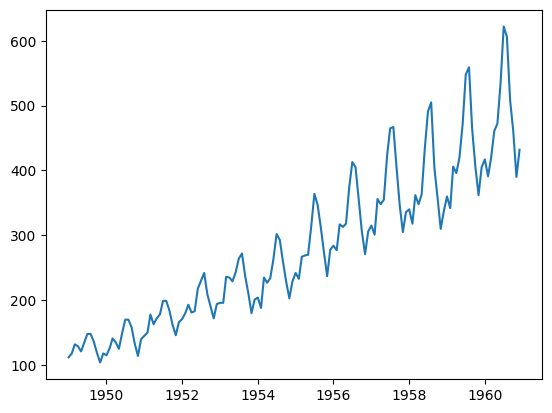

In [80]:
plt.plot(df['#Passengers'])
plt.show()

**Trend**: It is overall movement from left to right,in our graph we observe it is an upward trend(Increasing trend)
* **Seasonality**: The repeating wave like pattern ,we are able to see each year,shows seasonality
* **Residual error**: The repeating waves like pattern,we are able to see each year,shows seasonality


**In our data**
* Yes we do have Trend
* Yes we do have Seasonality
* Yes we do have Noise

Hence, My data is non
-stationary

#**Seasonal Decompose**
**It checks the presence of Components**

In [81]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [82]:
decompose = seasonal_decompose(df['#Passengers'])

In [83]:
decompose

Figure(640x480)


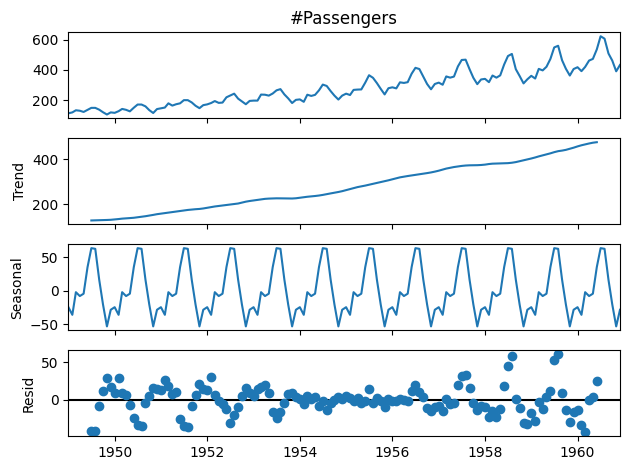

In [84]:
print(decompose.plot())

**To Check if the data is stationary or not**
* We will use ADF Test - (Augmented Dicky-Fuller Test)

In [85]:
from statsmodels.tsa.stattools import adfuller

In [86]:
result = adfuller(df['#Passengers'])

In [87]:
p_value=result[1]
if p_value <= 0.05:
    print("Null Hypothesis Rejected-Stationary")

else:
    print("Null hypothesis accepted - Non Stationary")

Null hypothesis accepted - Non Stationary


In [88]:
#Null hypothesis - Data is Not stationary
#Alternate Hypothesis - Data is stationary

**Rolling Mean**

In [89]:
rolling_mean = df.rolling(window=12).mean()
rolling_std = df.rolling(window=12).std()

In [90]:
rolling_mean.isnull().sum()

,0
#Passengers,11


In [91]:
rolling_std.isnull().sum()

,0
#Passengers,11


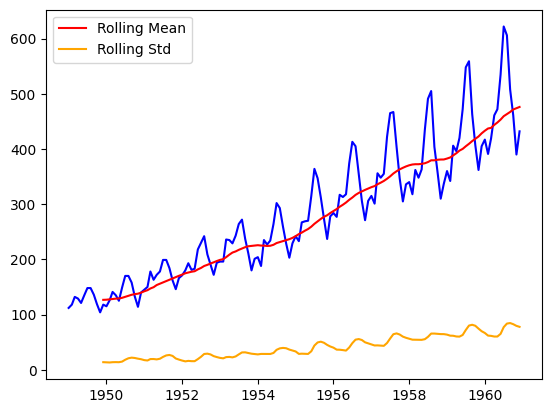

In [92]:
plt.plot(df,color = 'blue')
plt.plot(rolling_mean,color = 'red',label='Rolling Mean')
plt.plot(rolling_std,color = 'orange',label='Rolling Std')
plt.legend()
plt.show()

Let's Make Data Stationary
1. log transformation

In [93]:
log_df = np.log(df)
log_df

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [94]:
rolling_mean = log_df.rolling(window=12).mean()
rolling_std = log_df.rolling(window=12).std()

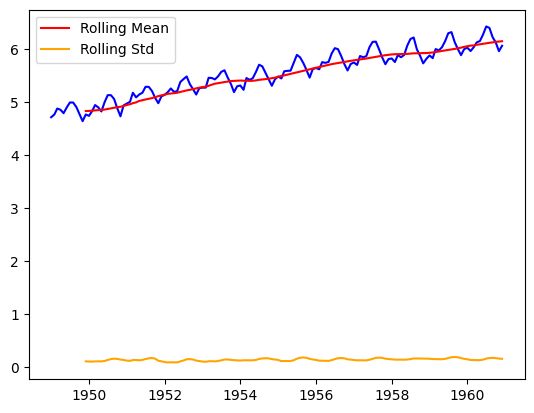

In [95]:
plt.plot(log_df,color = 'blue')
plt.plot(rolling_mean,color = 'red',label='Rolling Mean')
plt.plot(rolling_std,color = 'orange',label='Rolling Std')
plt.legend()
plt.show()

In [96]:
result=adfuller(log_df['#Passengers'])
p_value=result[1]
print(p_value)
if p_value <= 0.05:
    print("Null Hypothesis Rejected-Stationary")

else:
    print("Null hypothesis accepted - Non Stationary")

0.4223667747703874
Null hypothesis accepted - Non Stationary


**Differencing**
* Current value-Past value

In [97]:
diff_data = log_df.diff()
diff_data

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
...,...
1960-08-01,-0.026060
1960-09-01,-0.176399
1960-10-01,-0.097083


In [98]:
diff_data.dropna(inplace=True)

In [99]:
diff_data.head()

,#Passengers
Month,
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
1949-06-01,0.109484


In [100]:
rolling_mean = diff_data.rolling(window=12).mean()
rolling_std = diff_data.rolling(window=12).std()

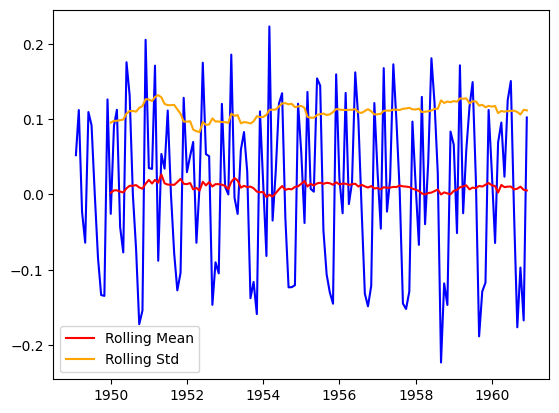

In [101]:
plt.plot(diff_data,color = 'blue')
plt.plot(rolling_mean,color = 'red',label='Rolling Mean')
plt.plot(rolling_std,color = 'orange',label='Rolling Std')
plt.legend()
plt.show()

In [102]:
result=adfuller(diff_data['#Passengers'])
p_value=result[1]
print(p_value)
if p_value <= 0.05:
    print("Null Hypothesis Rejected-Stationary")

else:
    print("Null hypothesis accepted - Non Stationary")

0.07112054815086184
Null hypothesis accepted - Non Stationary


**Shift**

In [103]:
diff_data = diff_data.shift(-1)
diff_data.tail()

,#Passengers
Month,
1960-08-01,-0.176399
1960-09-01,-0.097083
1960-10-01,-0.167251
1960-11-01,0.102279
1960-12-01,NaN


In [104]:
diff_data.dropna(inplace=True)

In [105]:
diff_data.tail()

,#Passengers
Month,
1960-07-01,-0.026060
1960-08-01,-0.176399
1960-09-01,-0.097083
1960-10-01,-0.167251
1960-11-01,0.102279


In [106]:
result=adfuller(diff_data['#Passengers'])
p_value=result[1]
print(p_value)
if p_value <= 0.05:
    print("Null Hypothesis Rejected-Stationary")

else:
    print("Null hypothesis accepted - Non Stationary")

0.048033972528754854
Null Hypothesis Rejected-Stationary


**ARIMA**
1. Auto Regression(P)
    * It used to control how many past values the model should look and make prediction
2. D(Difference)
    * The number of times we subtract the previous value to make data stationary
3. Moving Average(Q)
    * It finds how many past forecast errors that model should consider to improve my prediction
    

In [107]:
#We don't know P Q value but differencing 1 time and it gave me stationary
log_df # Because differencing will be done by ARIMA model

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [108]:
train = log_df.iloc[:120,:] #Past 10 year data
test = log_df.iloc[120:,:] #2 Year data
print(len(train),len(test))

120 24


In [109]:
from statsmodels.tsa.arima.model import ARIMA

In [110]:
model = ARIMA(train,order=(1,1,2)) # order = (p,d,q)
model

In [111]:
model = model.fit()

In [112]:
model

In [113]:
log_df['ArimaPred'] = model.predict(start = len(train),end = len(train)+len(test)-1)

In [114]:
log_df['ArimaPred']

,ArimaPred
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,5.912387
1960-09-01,5.912387
1960-10-01,5.912387


In [115]:
log_df.tail()

,#Passengers,ArimaPred
Month,,
1960-08-01,6.406880,5.912387
1960-09-01,6.230481,5.912387
1960-10-01,6.133398,5.912387
1960-11-01,5.966147,5.912387
1960-12-01,6.068426,5.912387


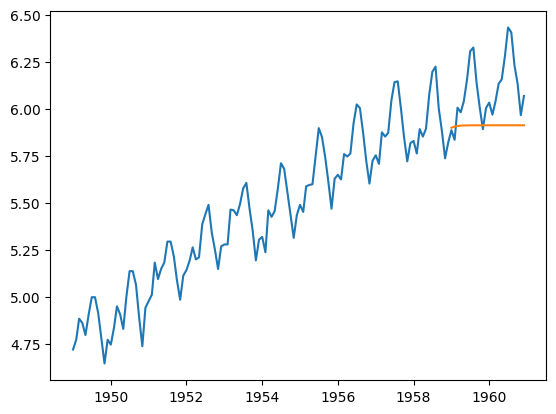

In [116]:
plt.plot(log_df)
plt.show()

In [117]:
import itertools
p = range(1,8)
d = range(1,2)
q = range(1,8)

In [118]:
pdq_combonation=list(itertools.product(p,d,q))

In [119]:
pdq_combonation

[(1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 1, 4),
 (1, 1, 5),
 (1, 1, 6),
 (1, 1, 7),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 1, 4),
 (2, 1, 5),
 (2, 1, 6),
 (2, 1, 7),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 1, 4),
 (3, 1, 5),
 (3, 1, 6),
 (3, 1, 7),
 (4, 1, 1),
 (4, 1, 2),
 (4, 1, 3),
 (4, 1, 4),
 (4, 1, 5),
 (4, 1, 6),
 (4, 1, 7),
 (5, 1, 1),
 (5, 1, 2),
 (5, 1, 3),
 (5, 1, 4),
 (5, 1, 5),
 (5, 1, 6),
 (5, 1, 7),
 (6, 1, 1),
 (6, 1, 2),
 (6, 1, 3),
 (6, 1, 4),
 (6, 1, 5),
 (6, 1, 6),
 (6, 1, 7),
 (7, 1, 1),
 (7, 1, 2),
 (7, 1, 3),
 (7, 1, 4),
 (7, 1, 5),
 (7, 1, 6),
 (7, 1, 7)]

In [120]:
len(pdq_combonation)

49

In [121]:
from sklearn.metrics import mean_squared_error

In [122]:
rmse = []
order1 = []
for pdq in pdq_combonation:
    model = ARIMA(train,order=pdq)
    model_fit = model.fit()
    pred = model_fit.predict(start = len(train),end = len(train)+len(test)-1)
    error = np.sqrt(mean_squared_error(test,pred))
    order1.append(pdq)
    rmse.append(error)


In [123]:
result = pd.DataFrame(index = order1, data = rmse, columns = ['RMSE'])
result.sort_values(by='RMSE',ascending = True)

,RMSE
"(5, 1, 4)",0.155013
"(6, 1, 4)",0.158187
"(7, 1, 7)",0.165622
"(7, 1, 5)",0.171635
"(7, 1, 4)",0.176668
"(6, 1, 5)",0.182591
"(7, 1, 2)",0.189217
"(7, 1, 3)",0.189703
"(5, 1, 5)",0.189813
"(1, 1, 5)",0.193841



**from above code pdq = (5,1,4)**

In [124]:
model = ARIMA(train, order = (5,1,4))
model = model.fit()

In [125]:
log_df['ArimaPred'] = model.predict(start = len(train),end = len(train) + len(test) -1)
log_df.tail()

,#Passengers,ArimaPred
Month,,
1960-08-01,6.406880,6.073565
1960-09-01,6.230481,6.016085
1960-10-01,6.133398,5.930742
1960-11-01,5.966147,5.886521
1960-12-01,6.068426,5.868482


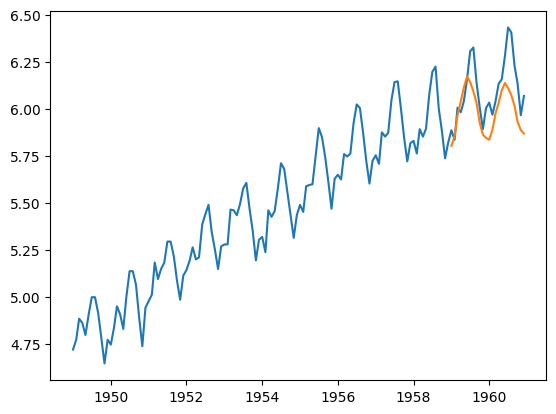

In [126]:
plt.plot(log_df)
plt.show()

**SARIMAX**

In [127]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [128]:
s_model = SARIMAX(train, order = (5,1,4),seasonal_order=(5,1,4,12)) # We have yearly data (shows month patterns s = 12)

In [129]:
s_model = s_model.fit()

In [130]:
log_df['SarimaxPred'] = s_model.predict(start = len(train),end = len(train) + len(test) -1)
log_df.tail()

,#Passengers,ArimaPred,SarimaxPred
Month,,,
1960-08-01,6.406880,6.073565,6.338585
1960-09-01,6.230481,6.016085,6.165951
1960-10-01,6.133398,5.930742,6.034450
1960-11-01,5.966147,5.886521,5.899023
1960-12-01,6.068426,5.868482,5.994766


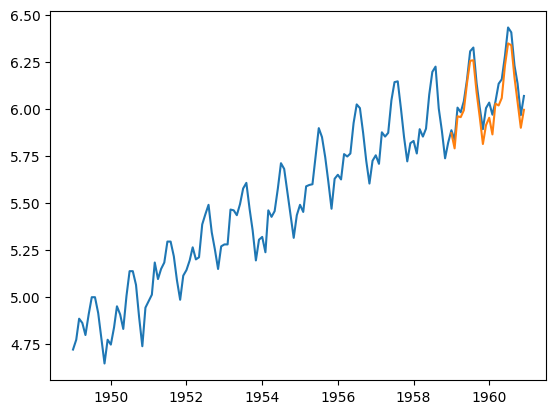

In [131]:
plt.plot(log_df['#Passengers'])
plt.plot(log_df['SarimaxPred'])
plt.show()

**Forecast**

Let's Predict the passenger data for next 5 years

In [132]:
future = s_model.forecast(steps = 60) # next 5 year
future

,predicted_mean
1959-01-01,5.870420
1959-02-01,5.789432
1959-03-01,5.960329
1959-04-01,5.955760
1959-05-01,5.992145
1959-06-01,6.138351
1959-07-01,6.255467
1959-08-01,6.258533
1959-09-01,6.087687
1959-10-01,5.958353


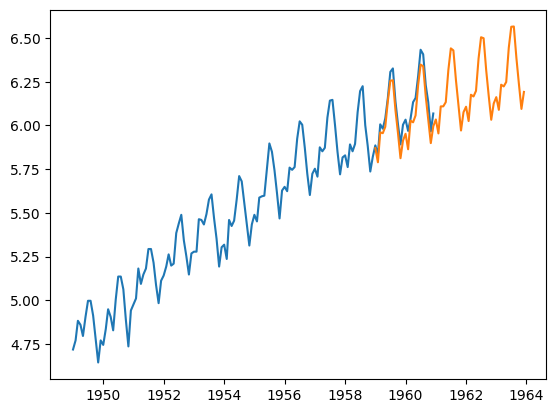

In [133]:
plt.plot(log_df['#Passengers'])
plt.plot(future)
plt.show()

**Reverse of log transformation is Exponential**

In [134]:
x = round(np.exp(future)) # it will showactual passengers traveling in future
x

,predicted_mean
1959-01-01,354.0
1959-02-01,327.0
1959-03-01,388.0
1959-04-01,386.0
1959-05-01,400.0
1959-06-01,463.0
1959-07-01,521.0
1959-08-01,522.0
1959-09-01,440.0
1959-10-01,387.0
